# Milestone_Project 2_SkimLit

## Introduction

Milestone Project 2: SkimLit 📄🔥
The purpose of this notebook is to build an NLP model to make reading medical abstracts easier.

It references two academic papers and one GitHub resource:

Paper 1 (dataset source): https://arxiv.org/abs/1710.06071

Paper 2 (model architecture): https://arxiv.org/abs/1612.05251

Notebook GitHub link:  
https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/09_SkimLit_nlp_milestone_project_2.ipynb (github.com in Bing)

In [1]:
# ============================================================================
# 🚀 AMD ROCm (GPU) - Setup de Aceleração
# ============================================================================

import sys
sys.path.append('/home/leonardo/Project_1/Tensorflow')  # Aponta para a pasta Tensorflow onde está o tf_startup.py
import tf_startup
import importlib
importlib.reload(tf_startup)

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Gráficos
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [14, 6]

I0000 00:00:1779815008.561977   27426 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779815008.566414   27426 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779815011.012647   27426 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779815011.015024   27426 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


⚠️ AVISO: Nenhuma GPU (ROCm) detectada pelo TensorFlow. O treino será feito na CPU.
The dtype policy mixed_float16 may run slowly because this machine does not have a GPU. Only Nvidia GPUs with compute capability of at least 7.0 run quickly with mixed_float16.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once
══════════════════════════════════════════════════════════════════════
✅ TensorFlow Otimizado - GPU AMD (ROCm)
══════════════════════════════════════════════════════════════════════
  🚀 Performance: Aceleração via GPU Ativada
  💻 GPUs Detectadas: 0
  ⚡ Mixed Precision: float16
  🔧 Memory Growth: Habilitado
  📦 TensorFlow: 2.21.0
══════════════════════════════════════════════════════════════════════

📝 FUNÇÕES DISPONÍVEIS:
  • create_fast_model(input_shape, num_classes, hidden_units)
  • get_fast_optimizer(learning_rate=0.01)
  • compile_fast(model, optimizer=None)
  

E0000 00:00:1779815011.875807   27426 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Get Data

Since we'll be replicating the paper above (PubMed 200k RCT), let's download the dataset they used.

We can do so from the authors’ GitHub:
https://github.com/Franck-Dernoncourt/pubmed-rct

In [2]:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct.git
!ls pubmed-rct

fatal: destination path 'pubmed-rct' already exists and is not an empty directory.
PubMed_200k_RCT	 PubMed_20k_RCT_numbers_replaced_with_at_sign
PubMed_20k_RCT	 README.md


In [3]:
# Check what files are in the PubMed-20k-RCT dataset folder
!ls pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign

dev.txt	 test.txt  train.txt


In [4]:
# Start our experiment using the PubMed-20k-RCT dataset replaced "@" sign
data_dir = "pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign"

In [5]:
# Check all of the filenames in the target directory
import os
filenames = [data_dir + filename for filename in os.listdir(data_dir)]
filenames

['pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_signtest.txt',
 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_signdev.txt',
 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_signtrain.txt']

## Preprocess data

Now we've got some text data, it's time to become one with it.
And one of the best ways to become one with the data is to...
>Visualize, visualize, visualize

So with that in mind, let's write a function to read in all of the lines of a target text file.

In [6]:
# Create function to read the lines of a document

def get_lines(filename):
    """
    Reads filename (a text filename) and returns a list of lines.
    
    Args:
        filename (str): The name of the file to be read.

    Returns:
        list: A list of strings containing all the lines from the file.
    
    """
    with open(filename, 'r') as f:
        return f.readlines()
    
# Lets read in the training lines
train_lines = get_lines(data_dir+"/train.txt") # This will be a list of strings where each string is a line from the file    
train_lines[:30] # Print the first 20 lines to see what they look like

['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and 

In [7]:
len(train_lines)

210040

Let's think about how we want our data to look...
How I think our data would be best represented...

```
[{'line_number': 0,
  'target': 'BACKGROUND',
  'text': 'Emotional eating is associated with overeating and the development of obesity .\n'
  'total_lines': 11},
  ...]
  ```

In [8]:
def get_lines(filename):
  """Lê um arquivo de texto e retorna as linhas em uma lista."""
  with open(filename, "r") as f:
    return f.readlines()

def preprocess_text_with_line_numbers(filename):
  """Retorna uma lista de dicionários contendo os dados de cada linha dos resumos."""
  input_lines = get_lines(filename) # Lê todas as linhas
  abstract_lines = "" # String para armazenar o texto do resumo atual
  abstract_samples = [] # Lista que vai guardar os dicionários processados
  
  for line in input_lines:
    if line.startswith("###"):
      # Se começar com ###, é o ID de um novo resumo
      abstract_id = line
      abstract_lines = "" # Reseta o texto pois é um resumo novo
      
    elif line.isspace():
      # Se for um espaço/linha em branco (\n), o resumo atual acabou e podemos processá-lo
      abstract_line_split = abstract_lines.splitlines() # Separa o resumo em uma lista de sentenças
      
      for abstract_line_number, abstract_line in enumerate(abstract_line_split):
        line_data = {} # Dicionário para cada linha
        target_text_split = abstract_line.split("\t") # Separa a classe (Label) do Texto pelo \t
        
        line_data["target"] = target_text_split[0] # Ex: 'OBJECTIVE'
        line_data["text"] = target_text_split[1].lower() # Ex: 'to investigate the efficacy...'
        line_data["line_number"] = abstract_line_number # Posição da linha no resumo
        line_data["total_lines"] = len(abstract_line_split) - 1 # Tamanho total do resumo
        
        abstract_samples.append(line_data) # Salva a linha estruturada na lista final
        
    else:
      # Se não for ID e nem linha vazia, adicionamos a linha na string do resumo atual
      abstract_lines += line
      
  return abstract_samples


In [9]:
%%time
# Get data from file and preprocess it
train_samples = preprocess_text_with_line_numbers(data_dir + "/train.txt")
val_samples = preprocess_text_with_line_numbers(data_dir + "/dev.txt") # dev is another name for validation set
test_samples = preprocess_text_with_line_numbers(data_dir + "/test.txt")
print(len(train_samples), len(val_samples), len(test_samples))


180040 30212 30135
CPU times: user 168 ms, sys: 45.7 ms, total: 214 ms
Wall time: 221 ms


In [10]:
# Check the first abstract of our training data
train_samples[:14]

[{'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'line_number': 0,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'line_number': 1,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'line_number': 2,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'line_number': 3,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'secondary outcome measures included the western ontari

Now that our data is the format of a list of dictionaries, how about we turn it into a dataframe to further visualialize? We can use the `pd.DataFrame()` function from the Pandas library. Here's an example

In [11]:
import pandas as pd
train_df = pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)
test_df = pd.DataFrame(test_samples)
train_df.head(14)


,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11
5,METHODS,"serum levels of interleukin @ ( il-@ ) , il-@ ...",5,11
6,RESULTS,there was a clinically relevant reduction in t...,6,11
7,RESULTS,the mean difference between treatment arms ( @...,7,11
8,RESULTS,"further , there was a clinically relevant redu...",8,11
9,RESULTS,these differences remained significant at @ we...,9,11


In [12]:
# Distribution of labels in our training data
train_df.target.value_counts()    

target
METHODS        59353
RESULTS        57953
CONCLUSIONS    27168
BACKGROUND     21727
OBJECTIVE      13839
Name: count, dtype: int64

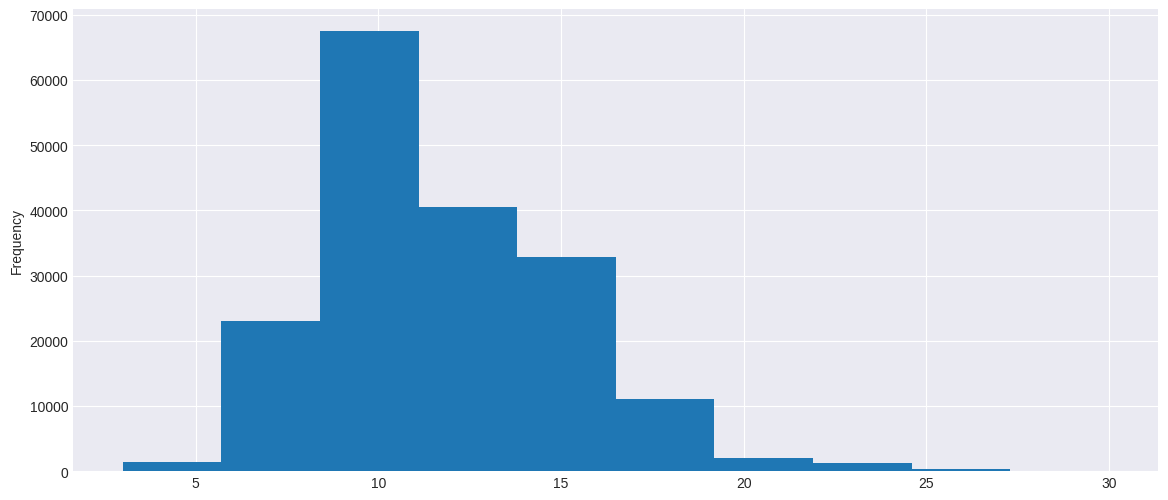

In [13]:
# Let's check the length of different lines
train_df.total_lines.plot.hist();

## Get List of sentences

In [14]:
# Convert abstract text lines into lists
train_sentences = train_df["text"].tolist()
val_sentences = val_df["text"].tolist()
test_sentences = test_df["text"].tolist()
len(train_sentences), len(val_sentences), len(test_sentences)

(180040, 30212, 30135)

In [15]:
# View the 10 sentences from the training data
train_sentences[:10]

['to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
 'secondary outcome measures included the western ontario and mcmaster universities osteoarthritis index scores , patient global assessment ( pga ) of the severity of knee oa , and @-min walk distance ( @mwd ) .',
 'serum levels of interleukin @ ( il-@ ) , il-@ , tumor necrosis factor ( tnf ) - , and high-sensitivity c-reactive protein ( hscrp ) were measured .',
 'there was a clinic

## Make numeric labels (ML models require numeric labels)

In [16]:
# One hot encode labels
from sklearn.preprocessing import OneHotEncoder

# Use sparse_output=False to get a dense (non-sparse) matrix
one_hot_encoder = OneHotEncoder(sparse_output=False) 

# Fit and transform the labels
train_labels_one_hot = one_hot_encoder.fit_transform(train_df["target"].to_numpy().reshape(-1, 1))
val_labels_one_hot = one_hot_encoder.transform(val_df["target"].to_numpy().reshape(-1, 1))
test_labels_one_hot = one_hot_encoder.transform(test_df["target"].to_numpy().reshape(-1, 1))



In [17]:
import tensorflow as tf
train_labels_one_hot

array([[0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

### Label encode labels

In [18]:
# Extract Labels ("target"columns) and dencode them into integers
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_df["target"].to_numpy())
val_labels_encoded = label_encoder.transform(val_df["target"].to_numpy())
test_labels_encoded = label_encoder.transform(test_df["target"].to_numpy())

# Check what training labels look like
train_labels_encoded

array([3, 2, 2, ..., 4, 1, 1])

In [19]:
# Get class names and number of classes from LabelEncoder instance
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
num_classes, class_names


(5,
 array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
       dtype=object))

## Starting a series of modelling experiments...

As usual, we're going to be trying out a bunch of different models and seeing which one works best.

And as always, we're going to start with a baseline (TF‑IDF Multinomial Naive Bayes classifier).

## Model 0: Getting a baseline

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Create the pipeline
model_0 = Pipeline([
    ('tf-idf', TfidfVectorizer()),
    ('clf', MultinomialNB()) # Use Multinomial Naive Bayes classifier
    ])

# Fit the model to the data
model_0.fit(X=train_sentences, y=train_labels_encoded)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tf-idf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [21]:
# Evaluate baseline model on calidation dataset
model_0.score(X=val_sentences,
              y=val_labels_encoded)

0.7218323844829869

In [22]:
# make predictions using our baseline model
baseline_preds = model_0.predict(val_sentences)
baseline_preds

array([4, 1, 3, ..., 4, 4, 1])

In [23]:
# Using helper function

from helper_functions import calculate_results

In [24]:
# Calculate results for baseline model
baseline_results = calculate_results(y_true=val_labels_encoded,
                            y_pred=baseline_preds)
baseline_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

In [25]:
train_sentences[:10]

['to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
 'secondary outcome measures included the western ontario and mcmaster universities osteoarthritis index scores , patient global assessment ( pga ) of the severity of knee oa , and @-min walk distance ( @mwd ) .',
 'serum levels of interleukin @ ( il-@ ) , il-@ , tumor necrosis factor ( tnf ) - , and high-sensitivity c-reactive protein ( hscrp ) were measured .',
 'there was a clinic

## Preparing our data (the text) for deep sequence models

Before we start building deep models, we've got to create vectorization and embedding layers

In [26]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

In [27]:
train_sentences[:10]

['to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
 'secondary outcome measures included the western ontario and mcmaster universities osteoarthritis index scores , patient global assessment ( pga ) of the severity of knee oa , and @-min walk distance ( @mwd ) .',
 'serum levels of interleukin @ ( il-@ ) , il-@ , tumor necrosis factor ( tnf ) - , and high-sensitivity c-reactive protein ( hscrp ) were measured .',
 'there was a clinic

In [28]:
# How long is each sentence on average?
sent_lens = [len(sentence.split()) for sentence in train_sentences]
avg_sent_len = np.mean(sent_lens)
avg_sent_len

26.338269273494777

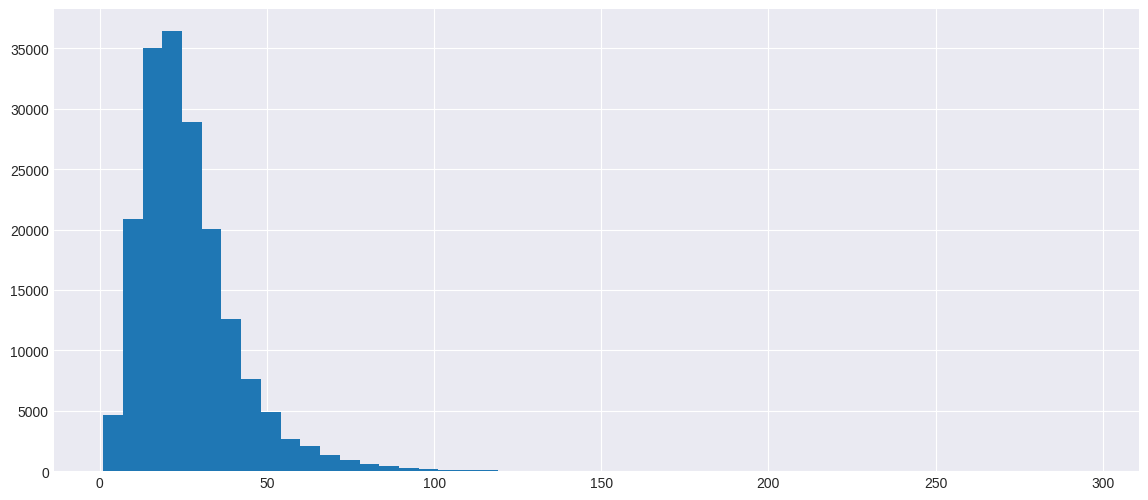

In [29]:
# What's the distribution look like?
import matplotlib.pyplot as plt
plt.hist(sent_lens, bins=50);  # ; dont show the values on the histogram

In [30]:
# How long of a sentence lenght covers 95% of examples?
output_seq_len = int(np.percentile(sent_lens, 95))
print(output_seq_len)

55


In [31]:
# Maximum sequence lenght in the training set
max(sent_lens)

296

### Create text vectorizer layer

We want to make a layer which maps ours texts

In [32]:
# How many words are in our vocabulary? taken from table 2 in the paper
max_tokens = 68000


In [33]:
# Create text vectorizer
from tensorflow.keras.layers.experimental.preprocessing import TextVectorization

text_vectorizer = TextVectorization(max_tokens=max_tokens, # number of words to keep in vocabulary
                                    output_sequence_length=output_seq_len) # desired length of the output sequence

In [34]:
# Adapt text vectorizer to training sentences
text_vectorizer.adapt(train_sentences)

In [35]:
# test out text vectorizer on random sentences
import random
target_sentence = random.choice(train_sentences)
print(f"Text: \n{target_sentence}")
print(f"\nLength of Text: {len(target_sentence.split())}")
print(f"\nVectorrized Text:, {text_vectorizer([target_sentence])}")


Text: 
sixteen weeks of oral levodopa or placebo administered @ times daily while patching the fellow eye @ hours daily .

Length of Text: 20

Vectorrized Text:, [[3397   53    4  217 4233   16   48  336  361  161  258 5635    2 5141
   672  227  161    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0]]


In [36]:
# How many words in our training vocabulary?
rct_20k_text_vocab = text_vectorizer.get_vocabulary()
print(f"Number of words in vocab: {len(rct_20k_text_vocab)}")
print(f"Most common words in the vocab: {rct_20k_text_vocab[:5]}")
print(f"Least common words in the vocab: {rct_20k_text_vocab[-5:]}")

Number of words in vocab: 64841
Most common words in the vocab: ['', '[UNK]', 'the', 'and', 'of']
Least common words in the vocab: ['aainduced', 'aaigroup', 'aachener', 'aachen', 'aaacp']


In [37]:
# Get the config of our text vectorizer
text_vectorizer.get_config()

{'name': 'text_vectorization',
 'trainable': True,
 'dtype': 'string',
 'batch_input_shape': (None,),
 'max_tokens': 68000,
 'standardize': 'lower_and_strip_punctuation',
 'split': 'whitespace',
 'ngrams': None,
 'output_mode': 'int',
 'output_sequence_length': 55,
 'pad_to_max_tokens': False,
 'sparse': False,
 'ragged': False,
 'vocabulary': None,
 'idf_weights': None,
 'encoding': 'utf-8',
 'vocabulary_size': 64841}

### Create custom text embedding

In [38]:
# Create token embedding layer
token_embed = layers.Embedding(input_dim=len(rct_20k_text_vocab),
                               output_dim=128, # Note: different embedding sizes results in different numbers of pars
                               mask_zero=True, # use masking to handle variable sequence lengths (save space)
                               name = "token_embedding")


In [39]:
# Show example embedding
print(f"Sentence before vectorization:\n {target_sentence}\n")
vectorized_sentence = text_vectorizer([target_sentence])
print(f"sentence after vectorization (before embedding:\n {vectorized_sentence})")
embedded_sentence = token_embed(vectorized_sentence)
print(f"sentence after embedding:\n{embedded_sentence}\n")
print(f"Embedded sentence shape: {embedded_sentence.shape}")

Sentence before vectorization:
 sixteen weeks of oral levodopa or placebo administered @ times daily while patching the fellow eye @ hours daily .

sentence after vectorization (before embedding:
 [[3397   53    4  217 4233   16   48  336  361  161  258 5635    2 5141
   672  227  161    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0]])
sentence after embedding:
[[[-0.01107   -0.02196    0.04575   ... -0.02147    0.03537    0.03607  ]
  [-0.006813   0.03275    0.00492   ...  0.013054   0.007786   0.00843  ]
  [ 0.02202   -0.004387  -0.00647   ... -0.01938    0.0469    -0.004383 ]
  ...
  [ 0.0143    -0.0004365 -0.03772   ... -0.02975   -0.01476   -0.01695  ]
  [ 0.0143    -0.0004365 -0.03772   ... -0.02975   -0.01476   -0.01695  ]
  [ 0.0143    -0.0004365 -0.03772   ... -0.02975   -0.01476   -0.01695  ]]]

Embedded sentence shape: (1, 55, 128)


E0000 00:00:1779815021.014261   27426 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


## Creating datasets (making sure our data loads as fast as possible)

We're going to setup our data to run as fast as possible with the TensorFlow tf.data API, many of the steps here are discussed at length in these two resourses:
* [Data Performance](https://www.tensorflow.org/guide/data_performance)
* [tf.data](https://www.tensorflow.org/guide/data)

In [40]:
# Rebuild everything in one cell
train_dataset = tf.data.Dataset.from_tensor_slices((train_sentences, train_labels_one_hot))
valid_dataset = tf.data.Dataset.from_tensor_slices((val_sentences, val_labels_one_hot))
test_dataset  = tf.data.Dataset.from_tensor_slices((test_sentences, test_labels_one_hot))

train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
valid_dataset = valid_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset  = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

# Confirm shapes
for x, y in train_dataset.take(1):
    print("train x:", x.shape, "| train y:", y.shape)

for x, y in valid_dataset.take(1):
    print("valid x:", x.shape, "| valid y:", y.shape)

train x: (32,) | train y: (32, 5)
valid x: (32,) | valid y: (32, 5)


In [41]:
# Turn our data into TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_sentences, train_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)

valid_dataset = tf.data.Dataset.from_tensor_slices((val_sentences, val_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((test_sentences, test_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)

train_dataset


<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>

In [42]:
train_labels_one_hot.shape, train_labels_one_hot[0]

((180040, 5), array([0., 0., 0., 1., 0.]))

In [43]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>

## Model 1 Conv1D with token embeddings

In [44]:
# Create 1D conv model to process sequences
inputs = layers.Input(shape=(), dtype=tf.string)  # scalar string per sample

text_vectors = text_vectorizer(inputs)         # (batch, seq_len)
token_embeddings = token_embed(text_vectors)   # (batch, seq_len, embed_dim)

x = layers.Conv1D(64, kernel_size=5, padding='same', activation='relu')(token_embeddings)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(5, activation="softmax")(x)

model_1 = tf.keras.Model(inputs, outputs)

model_1.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [45]:
model_1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None,)]                 0         
                                                                 
 text_vectorization (TextVe  (None, 55)                0         
 ctorization)                                                    
                                                                 
 token_embedding (Embedding  (None, 55, 128)           8299648   
 )                                                               
                                                                 
 conv1d (Conv1D)             (None, 55, 64)            41024     
                                                                 
 global_average_pooling1d (  (None, 64)                0         
 GlobalAveragePooling1D)                                         
                                                             

In [46]:
# Fit the model
history_model_1 = model_1.fit(train_dataset,
                              steps_per_epoch=int(0.1*len(train_dataset)),
                              epochs=3,
                              validation_data=valid_dataset,
                              validation_steps=int(0.1*len(valid_dataset)))

Epoch 1/3
562/562 [==============================] - 18s 31ms/step - loss: 0.9926 - accuracy: 0.6030 - val_loss: 0.7150 - val_accuracy: 0.7224
Epoch 2/3
562/562 [==============================] - 17s 30ms/step - loss: 0.7259 - accuracy: 0.7255 - val_loss: 0.6457 - val_accuracy: 0.7620
Epoch 3/3
562/562 [==============================] - 25s 45ms/step - loss: 0.6843 - accuracy: 0.7463 - val_loss: 0.6169 - val_accuracy: 0.7719


In [47]:
model_1.evaluate(valid_dataset)

945/945 [==============================] - 1s 1ms/step - loss: 0.6197 - accuracy: 0.7775


[0.6196569204330444, 0.7774725556373596]

In [48]:
# Make predictions (our model predicts prediction probabilities for each class)
model_1_pred_probs = model_1.predict(valid_dataset)
model_1_pred_probs, model_1_pred_probs.shape

945/945 [==============================] - 1s 1ms/step


(array([[4.182e-01, 1.804e-01, 6.537e-02, 3.242e-01, 1.161e-02],
        [4.133e-01, 3.289e-01, 1.101e-02, 2.404e-01, 6.577e-03],
        [2.354e-01, 2.020e-02, 4.791e-03, 7.393e-01, 4.554e-05],
        ...,
        [5.186e-06, 2.047e-03, 2.016e-03, 3.755e-06, 9.961e-01],
        [4.892e-02, 2.717e-01, 1.512e-01, 4.285e-02, 4.854e-01],
        [2.323e-01, 5.532e-01, 3.448e-02, 1.109e-01, 6.897e-02]],
       dtype=float16),
 (30212, 5))

In [49]:
model_1_preds = tf.argmax(model_1_pred_probs, axis=1)
model_1_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 4, 1])>

In [50]:
# calculate model_1 results
model_1_results = calculate_results(y_true=val_labels_encoded, y_pred=model_1_preds)
model_1_results

{'accuracy': 77.74725274725274,
 'precision': 0.7712187368279522,
 'recall': 0.7774725274725275,
 'f1': 0.7731294650423458}

In [51]:
baseline_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

## Model 2: Feature extraction with pretrained token embeddings

Now lets use pretrained word embeddings from TensorFlow Hub,
more specifically the universal sentence encoder! USE: https://tfhub.dev/google/universal-sentence-encoder/4

The paper originally used GloVe embeddings, however, we're
going to stick with the later created USE pretrained embeddings.



In [52]:
# Download pretrained TensorFlow Hub USE
import tensorflow_hub as hub
use_url = "https://tfhub.dev/google/universal-sentence-encoder/4"
tf_hub_embedding_layer = hub.KerasLayer(use_url, 
                                        input_shape=[], 
                                        dtype=tf.string, 
                                        trainable=False, 
                                        name="universal_sentence_encoder")

In [53]:
#%pip install tensorflow-hub

In [54]:
# test out the pretrained embedding on a random sentence
random_train_sentence = random.choice(train_sentences)
print(f"RandomSentence: \n{random_train_sentence}\n")
use_embedded_sentence = tf_hub_embedding_layer([random_train_sentence])
print(f"USE embedded sentence:\n {use_embedded_sentence}\n") # after embedding
print(f"USE embedded sentence shape: {use_embedded_sentence.shape}") # USE produces a 512 dimensional embedding for each sentence

RandomSentence: 
it can be approximate ( using individual ldl-cholesterol values ) , that after maximal possible up-titration of statin , the adherence to recent ldl-cholesterol target may improve up to @ % .

USE embedded sentence:
 [[ 8.90460424e-03 -2.31611561e-02 -6.79414570e-02 -6.64496943e-02
  -5.65641075e-02 -5.16536348e-02 -5.81613509e-03  1.21335899e-02
  -2.50894893e-02  7.72504881e-02 -8.42212513e-03  1.86406076e-02
  -5.39832972e-02  8.10877159e-02  5.62615693e-02  4.55583930e-02
   1.41996555e-02  3.05054206e-02 -1.38386176e-03 -1.96451098e-02
  -6.51685372e-02  4.83059771e-02 -3.33968848e-02  1.17736012e-02
   3.20253335e-02  5.46022467e-02 -5.34608401e-02 -5.97947184e-03
  -6.19109496e-02 -3.22820432e-03 -8.46984535e-02 -9.18765087e-03
   4.23814096e-02  5.49608842e-02  1.56964231e-02  1.43294521e-02
   3.67048904e-02 -1.02939410e-02 -5.78462798e-03 -4.11894955e-02
  -2.18731929e-02 -1.35713974e-02 -1.84559952e-02 -6.11376725e-02
   5.31803630e-02  2.80356053e-02  7.918

### Building and fitting an NLP feature extraction model using pretrained embeddings tensorFlow Hub

In [55]:
# Define feature extractor model using TF Hub layer
inputs = layers.Input(shape=[], dtype=tf.string)
pretrained_embedding = tf_hub_embedding_layer(inputs) # tokenize text and create embedding of each sequence (512-dimensional vector)
x = layers.Dense(128, activation="relu")(pretrained_embedding)
outputs = layers.Dense(5, activation="softmax")(x) # output layer with 5 units for 5 classes and softmax activation for probabilities
model_2 = tf.keras.Model(inputs=inputs, outputs=outputs, name="model_2_USE_feature_extractor")

model_2.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [56]:
model_2.summary()

Model: "model_2_USE_feature_extractor"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None,)]                 0         
                                                                 
 universal_sentence_encoder  (None, 512)               256797824 
  (KerasLayer)                                                   
                                                                 
 dense_1 (Dense)             (None, 128)               65664     
                                                                 
 dense_2 (Dense)             (None, 5)                 645       
                                                                 
Total params: 256864133 (979.86 MB)
Trainable params: 66309 (259.02 KB)
Non-trainable params: 256797824 (979.61 MB)
_________________________________________________________________


In [57]:
# Fit model_2 to the data
history_model_2 = model_2.fit(train_dataset,
                              steps_per_epoch=int(0.1*len(train_dataset)),
                              epochs=3,
                              validation_data=valid_dataset,
                              validation_steps=int(0.1*len(valid_dataset)))

Epoch 1/3
562/562 [==============================] - 4s 4ms/step - loss: 0.9184 - accuracy: 0.6497 - val_loss: 0.7938 - val_accuracy: 0.6885
Epoch 2/3
562/562 [==============================] - 2s 4ms/step - loss: 0.7662 - accuracy: 0.7042 - val_loss: 0.7493 - val_accuracy: 0.7061
Epoch 3/3
562/562 [==============================] - 2s 4ms/step - loss: 0.7468 - accuracy: 0.7153 - val_loss: 0.7302 - val_accuracy: 0.7194


In [58]:
# Evaluate model_2 on the validation dataset
model_2.evaluate(valid_dataset)

  1/945 [..............................] - ETA: 8s - loss: 1.0869 - accuracy: 0.4688

945/945 [==============================] - 3s 3ms/step - loss: 0.7344 - accuracy: 0.7187


[0.7343823909759521, 0.7187210321426392]

In [59]:
# make some predictions with model_2
model_2_pred_probs = model_2.predict(valid_dataset)
model_2_pred_probs, model_2_pred_probs.shape

945/945 [==============================] - 3s 3ms/step


(array([[0.4336  , 0.3674  , 0.002787, 0.1869  , 0.009415],
        [0.3213  , 0.523   , 0.005127, 0.1473  , 0.003536],
        [0.2113  , 0.1515  , 0.0195  , 0.5835  , 0.03464 ],
        ...,
        [0.00218 , 0.005833, 0.05515 , 0.001087, 0.936   ],
        [0.003502, 0.0448  , 0.2054  , 0.001524, 0.7446  ],
        [0.1616  , 0.2764  , 0.4858  , 0.0096  , 0.0672  ]], dtype=float16),
 (30212, 5))

In [60]:
# Convert the prediction probabilities found with feature extractor model to label predictions
model_2_preds = tf.argmax(model_2_pred_probs, axis=1)
model_2_preds, model_2_preds.shape

(<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 1, 3, ..., 4, 4, 2])>,
 TensorShape([30212]))

In [61]:
# Calculate model_2 results from TF Hub feature extractor model pretrained embeddings resultus on the validation dataset
model_2_results = calculate_results(y_true=val_labels_encoded, y_pred=model_2_preds)
model_2_results

{'accuracy': 71.87210379981465,
 'precision': 0.7189940618525182,
 'recall': 0.7187210379981465,
 'f1': 0.7158175525127455}

In [62]:
baseline_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

# Model 3: Conv1D with character embeddings  
The paper which we're replicating states they used a combination of token and character-level embeddings.
Previously we've token-level embeddings but we'll need to do similar steps for characters if we want to use char-level embeddings.

### Create a character level tokenizer

In [63]:
train_sentences[:5]

['to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
 'secondary outcome measures included the western ontario and mcmaster universities osteoarthritis index scores , patient global assessment ( pga ) of the severity of knee oa , and @-min walk distance ( @mwd ) .']

In [64]:
# Make function to split sentences into characters
def split_chars(text):
    return " ".join(list(text))

# Text splitting non-character level sequenceinto characters
split_chars(random_train_sentence)

'i t   c a n   b e   a p p r o x i m a t e   (   u s i n g   i n d i v i d u a l   l d l - c h o l e s t e r o l   v a l u e s   )   ,   t h a t   a f t e r   m a x i m a l   p o s s i b l e   u p - t i t r a t i o n   o f   s t a t i n   ,   t h e   a d h e r e n c e   t o   r e c e n t   l d l - c h o l e s t e r o l   t a r g e t   m a y   i m p r o v e   u p   t o   @   %   .'

In [65]:
# Split sequence-level data into character-level data splits
train_chars = [split_chars(sentence) for sentence in train_sentences]
val_chars = [split_chars(sentence) for sentence in val_sentences]
test_chars = [split_chars(sentence) for sentence in test_sentences]
print(train_chars[:5])

['t o   i n v e s t i g a t e   t h e   e f f i c a c y   o f   @   w e e k s   o f   d a i l y   l o w - d o s e   o r a l   p r e d n i s o l o n e   i n   i m p r o v i n g   p a i n   ,   m o b i l i t y   ,   a n d   s y s t e m i c   l o w - g r a d e   i n f l a m m a t i o n   i n   t h e   s h o r t   t e r m   a n d   w h e t h e r   t h e   e f f e c t   w o u l d   b e   s u s t a i n e d   a t   @   w e e k s   i n   o l d e r   a d u l t s   w i t h   m o d e r a t e   t o   s e v e r e   k n e e   o s t e o a r t h r i t i s   (   o a   )   .', 'a   t o t a l   o f   @   p a t i e n t s   w i t h   p r i m a r y   k n e e   o a   w e r e   r a n d o m i z e d   @ : @   ;   @   r e c e i v e d   @   m g / d a y   o f   p r e d n i s o l o n e   a n d   @   r e c e i v e d   p l a c e b o   f o r   @   w e e k s   .', 'o u t c o m e   m e a s u r e s   i n c l u d e d   p a i n   r e d u c t i o n   a n d   i m p r o v e m e n t   i n   f u n c t i o n   s c o r e s   a n 

In [66]:
# What's the average character length of our sentences?
char_lens = [len(sentence) for sentence in train_sentences]
avg_char_len = np.mean(char_lens)
avg_char_len

149.3662574983337

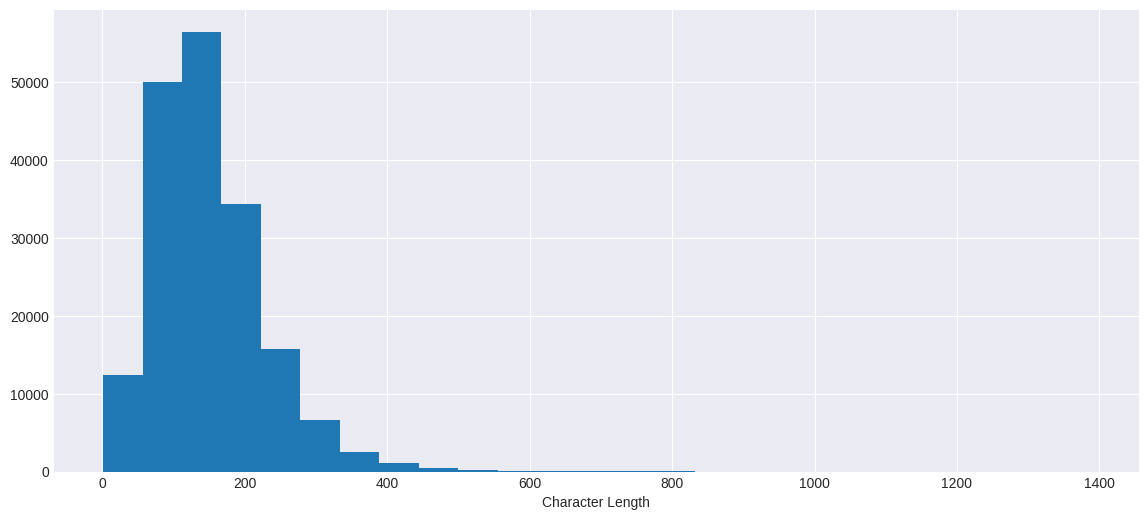

In [68]:
# Check the distribution of our sequence character lengths
import matplotlib.pyplot as plt
plt.hist(char_lens, bins=25);
plt.xlabel('Character Length');


In [69]:
# Find what character length covers 95% of sequences
output_seq_char_len = int(np.percentile(char_lens, 95))
output_seq_char_len

290

In [71]:
# get all keyboard characters (unique characters in the training set)
import string
alphabet = string.ascii_lowercase + string.digits + string.punctuation
alphabet

'abcdefghijklmnopqrstuvwxyz0123456789!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
# Create char-level tokern vectorizer instance
NUM_CHAR_TOKENS = len(alphabet) + 2 # plus 2 for padding and OOV tokens (00V = out of vocabulary, '[UNK]')
char_vectorizer = TextVectorization(max_tokens=NUM_CHAR_TOKENS,
                                    output_sequence_length=output_seq_char_len,
                                    standardize=None, # set to none if you leave the punctuation in your text (which we do in this case)
                                    name="char_vectorizer")

In [74]:
# Adapt character vectorizer to training character
char_vectorizer.adapt(train_chars)

In [75]:
# Check character vocab stats
char_vocab = char_vectorizer.get_vocabulary()
print(f"Number of characters in vocab: {len(char_vocab)}")
print(f"Most common characters in the vocab: {char_vocab[:5]}")
print(f"Least common characters in the vocab: {char_vocab[-5:]}")

Number of characters in vocab: 57
Most common characters in the vocab: ['', '[UNK]', 'e', 't', 'i']
Least common characters in the vocab: ['|', '"', ']', '\\', '[']


In [86]:
# test out character vectorizer
random_train_chars = random.choice(train_chars)
print(f"Charified text:\n {random_train_chars}")
print(f"Length of random_train_chars: {len(random_train_chars.split())}")
vectorized_chars = char_vectorizer([random_train_chars])
print(f"\Vectorized chars:\n {vectorized_chars}")
print(f"\nLength of vectorized chars: {len(vectorized_chars[0])}")

Charified text:
 r a n d o m   s a m p l e   o f   c o m m u n i t i e s   i n   m a n a g u a   ,   c a p i t a l   o f   n i c a r a g u a   ,   a n d   t h r e e   c o a s t a l   r e g i o n s   i n   g u e r r e r o   s t a t e   i n   t h e   s o u t h   o f   m e x i c o   .
Length of random_train_chars: 110
\Vectorized chars:
 [[ 8  5  6 10  7 15  9  5 15 14 12  2  7 17 11  7 15 15 16  6  4  3  4  2
   9  4  6 15  5  6  5 18 16  5 24 11  5 14  4  3  5 12  7 17  6  4 11  5
   8  5 18 16  5 24  5  6 10  3 13  8  2  2 11  7  5  9  3  5 12  8  2 18
   4  7  6  9  4  6 18 16  2  8  8  2  8  7  9  3  5  3  2  4  6  3 13  2
   9  7 16  3 13  7 17 15  2 30  4 11  7 25  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 

# Creating a character-level embedding

In [88]:
# Create char embedding layer
char_embed = layers.Embedding(input_dim=len(char_vocab), # number of characters in vocab
                              output_dim=25, # Note: different embedding sizes results in different numbers of pars https://arxiv.org/pdf/1612.05251.pdf (Figure 1)
                              mask_zero=True, # use masking to handle variable sequence lengths (save space)
                              name = "char_embedding")

In [93]:
# test our character embedding layer
print(f"Charfield text:\n {random_train_chars}\n")
char_embedded_example = char_embed(char_vectorizer([random_train_chars]))
print(f"Char embedded example:\n {char_embedded_example}\n") # after embedding
print(f"Char embedded example shape: {char_embedded_example.shape}")

Charfield text:
 r a n d o m   s a m p l e   o f   c o m m u n i t i e s   i n   m a n a g u a   ,   c a p i t a l   o f   n i c a r a g u a   ,   a n d   t h r e e   c o a s t a l   r e g i o n s   i n   g u e r r e r o   s t a t e   i n   t h e   s o u t h   o f   m e x i c o   .

Char embedded example:
 [[[-0.049     0.034     0.0463   ...  0.0282    0.0444   -0.00249 ]
  [-0.00972  -0.04944   0.02695  ... -0.04517  -0.02733   0.0398  ]
  [ 0.003567 -0.04974  -0.02393  ... -0.04233  -0.03387  -0.01339 ]
  ...
  [-0.01276  -0.04227  -0.02827  ...  0.03503   0.04108   0.03165 ]
  [-0.01276  -0.04227  -0.02827  ...  0.03503   0.04108   0.03165 ]
  [-0.01276  -0.04227  -0.02827  ...  0.03503   0.04108   0.03165 ]]]

Char embedded example shape: (1, 290, 25)


In [94]:
len(random_train_chars)

265

### Building a Conv1D model to fit on character embeddings

In [ ]:
# make a Conv1D on chars only
inputs = layers.Input(shape=(), dtype=tf.string)
char_vectors = char_vectorizer(inputs)
char_embeddings = char_embed(char_vectors)
x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(char_embeddings)
x = layers.GlobalMaxPooling1D()(x) # try global max pooling instead of average pooling to see if it improves results (max pooling takes the maximum value across the sequence dimension, while average pooling takes the average value across the sequence dimension)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model_3 = tf.keras.Model(inputs, outputs, name="model_3_conv1D_char_embeddings")

# Compile model_3
model_3.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)
model_3.summary()

Model: "model_3_conv1D_char_embeddings"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None,)]                 0         
                                                                 
 char_vectorizer (TextVecto  (None, 290)               0         
 rization)                                                       
                                                                 
 char_embedding (Embedding)  (None, 290, 25)           1425      
                                                                 
 conv1d_2 (Conv1D)           (None, 290, 64)           8064      
                                                                 
 global_max_pooling1d (Glob  (None, 64)                0         
 alMaxPooling1D)                                                 
                                                                 
 dropout_2 (Dropout)         (None, 

In [100]:
# Create char level datasets
train_char_dataset = tf.data.Dataset.from_tensor_slices((train_chars, train_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)
valid_char_dataset = tf.data.Dataset.from_tensor_slices((val_chars, val_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)
test_char_dataset = tf.data.Dataset.from_tensor_slices((test_chars, test_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)

In [101]:
train_char_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>

In [102]:
# Fit the char level model
model_3_history = model_3.fit(train_char_dataset,
                              steps_per_epoch=int(0.1*len(train_char_dataset)),
                              epochs=3,
                              validation_data=valid_char_dataset,
                              validation_steps=int(0.1*len(valid_char_dataset)))

Epoch 1/3
562/562 [==============================] - 4s 6ms/step - loss: 1.2515 - accuracy: 0.4864 - val_loss: 1.1175 - val_accuracy: 0.5479
Epoch 2/3
562/562 [==============================] - 3s 6ms/step - loss: 1.1097 - accuracy: 0.5498 - val_loss: 1.0211 - val_accuracy: 0.5941
Epoch 3/3
562/562 [==============================] - 3s 6ms/step - loss: 1.0408 - accuracy: 0.5887 - val_loss: 0.9576 - val_accuracy: 0.6213


In [103]:
# make predictions with char level model
model_3_pred_probs = model_3.predict(valid_char_dataset)
model_3_pred_probs, model_3_pred_probs.shape

945/945 [==============================] - 1s 1ms/step


(array([[0.2112  , 0.375   , 0.1517  , 0.1525  , 0.10986 ],
        [0.198   , 0.4082  , 0.0883  , 0.168   , 0.1371  ],
        [0.1077  , 0.23    , 0.3901  , 0.0698  , 0.2018  ],
        ...,
        [0.005188, 0.01164 , 0.10834 , 0.00243 , 0.872   ],
        [0.03345 , 0.11865 , 0.2656  , 0.011696, 0.5703  ],
        [0.354   , 0.2397  , 0.1277  , 0.1842  , 0.0937  ]], dtype=float16),
 (30212, 5))

In [104]:
# Convert prediction probabilities t class labels
model_3_preds = tf.argmax(model_3_pred_probs, axis=1)
model_3_preds, model_3_preds.shape

(<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([1, 1, 2, ..., 4, 4, 0])>,
 TensorShape([30212]))

In [105]:
# Calculate results for char level model
model_3_results = calculate_results(y_true=val_labels_encoded, y_pred=model_3_preds)
model_3_results

{'accuracy': 62.481795313120614,
 'precision': 0.635147687604224,
 'recall': 0.6248179531312061,
 'f1': 0.6103515688667166}